# Preprocessing for PNR nsta Data

This notebook loads catalog and pumping data for `PNR_1z` and `PNR_2`, aligns timestamps, and prepares minute-level injection rate series.


In [1]:
import glob
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import pandas as pd


def resolve_data_root():
    for candidate in (Path("data"), Path("../data")):
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data directory. Expected ./data or ../data.")


DATA_ROOT = resolve_data_root()
print(f"Using DATA_ROOT: {DATA_ROOT}")

Using DATA_ROOT: /root/autodl-tmp/chuandian_eq/data


## 1) Load catalog data

In [2]:
CATALOG_TIME_FMT = "%d:%m:%y:%H:%M:%S"


def load_catalog_pair(catalog_path, nsta_path):
    df_catalog = pd.read_csv(catalog_path, index_col="ts").sort_index()
    df_catalog.index = pd.to_datetime(df_catalog.index)

    df_nsta = pd.read_csv(nsta_path, skiprows=[1])
    for col in ["UTC Time", "Job Time"]:
        if col in df_nsta.columns:
            df_nsta[col] = pd.to_datetime(df_nsta[col], format=CATALOG_TIME_FMT)
    df_nsta = df_nsta.set_index("UTC Time").sort_index()

    return df_catalog, df_nsta


def compare_indices(a, b, name_a="A", name_b="B", show=True):
    set_a, set_b = set(a.tolist()), set(b.tolist())
    only_a = set_a - set_b
    only_b = set_b - set_a
    if show:
        if not only_a and not only_b:
            print(f"{name_a} and {name_b} indices are identical.")
        else:
            print(f"Only in {name_a}: {len(only_a)}")
            print(f"Only in {name_b}: {len(only_b)}")
    return {"only_in_" + name_a: list(only_a), "only_in_" + name_b: list(only_b)}

In [3]:
df_cat1, df_cat1_nsta = load_catalog_pair(
    DATA_ROOT / "PNR_1z/raw/PNR_1z_catalog.csv",
    DATA_ROOT / "PNR_1z/raw/PNR-1z_ms_catalogue_nsta.csv",
)
df_cat2, df_cat2_nsta = load_catalog_pair(
    DATA_ROOT / "PNR_2/raw/PNR_2_catalog.csv",
    DATA_ROOT / "PNR_2/raw/PNR-2_ms_catalogue_nsta.csv",
)

cmp_res1 = compare_indices(df_cat1.index, df_cat1_nsta.index, name_a="df_cat1", name_b="df_cat1_nsta")
cmp_res2 = compare_indices(df_cat2.index, df_cat2_nsta.index, name_a="df_cat2", name_b="df_cat2_nsta")

pd.DataFrame(
    [
        {
            "dataset": "PNR_1z",
            "catalog_max_mag": df_cat1["Magnitude"].max(),
            "nsta_max_sp_mag": df_cat1_nsta["SP_MAGNITUDE"].max(),
            "only_in_catalog": len(cmp_res1["only_in_df_cat1"]),
            "only_in_nsta": len(cmp_res1["only_in_df_cat1_nsta"]),
        },
        {
            "dataset": "PNR_2",
            "catalog_max_mag": df_cat2["Magnitude"].max(),
            "nsta_max_sp_mag": df_cat2_nsta["SP_MAGNITUDE"].max(),
            "only_in_catalog": len(cmp_res2["only_in_df_cat2"]),
            "only_in_nsta": len(cmp_res2["only_in_df_cat2_nsta"]),
        },
    ]
)

Only in df_cat1: 881
Only in df_cat1_nsta: 1282
Only in df_cat2: 1839
Only in df_cat2_nsta: 33


,dataset,catalog_max_mag,nsta_max_sp_mag,only_in_catalog,only_in_nsta
0,PNR_1z,1.6000,1.155,881,1282
1,PNR_2,2.7889,1.145,1839,33


## 2) Process injection sequences

In [4]:
def load_injection_rates(path):
    df = pd.read_csv(path, index_col="ts").sort_index()
    df.index = pd.to_datetime(df.index)
    return df



df_inj1 = load_injection_rates(DATA_ROOT / "PNR_1z/raw/PNR-1z_injection_rates.csv")
df_inj2 = load_injection_rates(DATA_ROOT / "PNR_2/raw/PNR-2_injection_rates.csv")

In [5]:
def add_utc_column(df):
    df = df.copy()
    df["JobTime"] = pd.to_datetime(df["JobTime"], format=CATALOG_TIME_FMT)
    df["JobTime"] = df["JobTime"].dt.tz_localize("Europe/London", ambiguous="infer")
    df["UTCTime"] = df["JobTime"].dt.tz_convert("UTC").dt.tz_localize(None)
    return df


def process_pumping_data(csv_files, pattern=r"Sleeve(\d+)", verbose=False):
    df_list = []
    for file in sorted(csv_files):
        df = pd.read_csv(file, skiprows=[1]).dropna(how="all")
        df = add_utc_column(df).dropna(how="all")

        match = re.search(pattern, file)
        stage = int(match.group(1)) if match else 0

        df["Stage"] = stage
        df["INJ_RATE"] = pd.to_numeric(df["INJ_RATE"], errors="coerce")
        df = df[["UTCTime", "Stage", "INJ_RATE"]].dropna(subset=["UTCTime"])

        if verbose:
            print(f"Processing Stage {stage}: {df['UTCTime'].min()} to {df['UTCTime'].max()}")

        df = df.set_index("UTCTime").sort_index()
        df = df.groupby(level=0).agg({"Stage": "first", "INJ_RATE": "mean"})
        df_list.append(df)

    if not df_list:
        return pd.DataFrame(columns=["Stage", "INJ_RATE"])

    df_result = pd.concat(df_list).sort_index()

    if df_result.index.duplicated().any():
        df_result = df_result.groupby(level=0).agg({"Stage": "first", "INJ_RATE": "mean"})

    if verbose:
        print(f"Total rows: {len(df_result)}")
        print(f"Duplicate indices remaining: {df_result.index.duplicated().any()}")

    return df_result

In [6]:
base_dir1 = DATA_ROOT / "PNR_1z/raw/Pumping Data"
base_dir2 = DATA_ROOT / "PNR_2/raw/Pumping Data"

csv_files1 = glob.glob(os.path.join(base_dir1, "*.csv"))
csv_files2 = glob.glob(os.path.join(base_dir2, "*.csv"))

df_inj1_nsta = process_pumping_data(csv_files1, verbose=True)
df_inj2_nsta = process_pumping_data(csv_files2)

pd.DataFrame(
    [
        {"dataset": "PNR_1z", "rows": len(df_inj1_nsta), "start": df_inj1_nsta.index.min(), "end": df_inj1_nsta.index.max()},
        {"dataset": "PNR_2", "rows": len(df_inj2_nsta), "start": df_inj2_nsta.index.min(), "end": df_inj2_nsta.index.max()},
    ]
)

Processing Stage 1: 2018-10-15 08:56:31 to 2018-10-16 07:22:55
Processing Stage 1: 2018-10-16 10:23:49 to 2018-10-17 07:06:59


/root/autodl-tmp/tmp/ipykernel_5541/916658760.py:12: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=[1]).dropna(how="all")


Processing Stage 2: 2018-10-17 07:49:27 to 2018-10-18 07:16:29
Processing Stage 3: 2018-10-18 09:47:35 to 2018-10-19 07:46:25
Processing Stage 12: 2018-10-19 07:58:25 to 2018-10-20 07:09:26
Processing Stage 12: 2018-10-20 07:32:22 to 2018-10-22 07:11:28
Processing Stage 13: 2018-10-22 07:24:55 to 2018-10-23 07:47:13
Processing Stage 14: 2018-10-23 07:59:56 to 2018-10-24 07:15:01
Processing Stage 18: 2018-10-24 07:56:09 to 2018-10-25 07:12:13
Processing Stage 22: 2018-10-25 07:39:28 to 2018-10-26 07:28:52
Processing Stage 30: 2018-10-26 07:52:19 to 2018-10-27 07:10:53
Processing Stage 31: 2018-10-27 07:26:19 to 2018-10-27 22:59:44
Processing Stage 32: 2018-10-29 08:49:15 to 2018-10-30 07:39:57
Processing Stage 41: 2018-10-30 08:17:42 to 2018-10-31 07:37:33
Processing Stage 37: 2018-10-31 08:48:59 to 2018-11-01 07:37:26
Processing Stage 38: 2018-11-02 07:59:53 to 2018-11-02 23:59:28
Processing Stage 37: 2018-12-08 07:35:21 to 2018-12-08 23:59:59
Processing Stage 37: 2018-12-10 07:37:16 t

/root/autodl-tmp/tmp/ipykernel_5541/916658760.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=[1]).dropna(how="all")


,dataset,rows,start,end
0,PNR_1z,1963011,2018-10-15 08:56:31,2018-12-17 15:20:13
1,PNR_2,875362,2019-08-13 15:30:17,2019-08-23 22:59:59


In [7]:
def resample_and_clip_inj_rate(df, upper_bound=20):
    df_min = df.resample("1Min").mean().interpolate()
    df_min["INJ_RATE"] = df_min["INJ_RATE"].clip(lower=0, upper=upper_bound)
    return df_min



df_inj1_m_nsta = resample_and_clip_inj_rate(df_inj1_nsta)
df_inj2_m_nsta = resample_and_clip_inj_rate(df_inj2_nsta)

## 3) Quick visualization

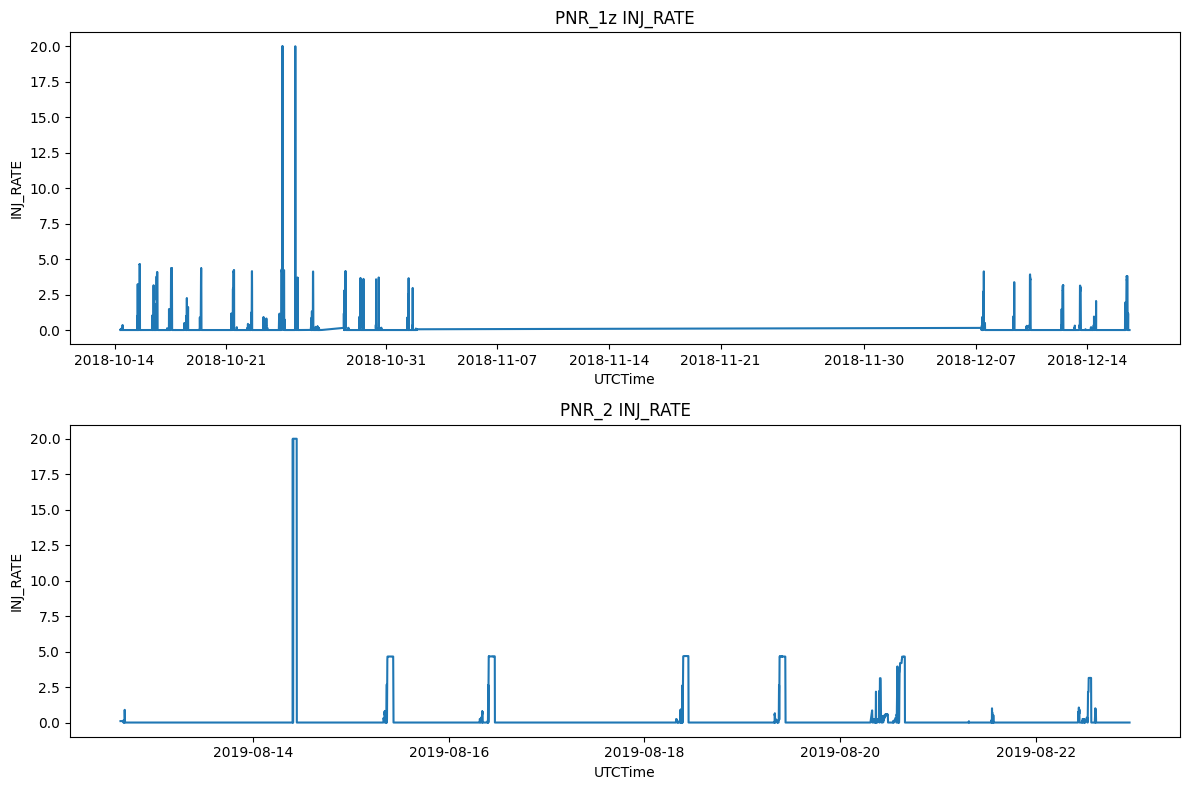

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for ax, df, title in [
    (axes[0], df_inj1_m_nsta, "PNR_1z INJ_RATE"),
    (axes[1], df_inj2_m_nsta, "PNR_2 INJ_RATE"),
]:
    ax.plot(df.index, df["INJ_RATE"])
    ax.set_title(title)
    ax.set_xlabel("UTCTime")
    ax.set_ylabel("INJ_RATE")

plt.tight_layout()
plt.show()